In [2]:
import torch
import torch.nn as nn

import matplotlib.pyplot as plt
import pandas as pd

from torchvision import models, transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

from sklearn.metrics import confusion_matrix

In [3]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)

cpu


In [4]:
transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )

])

dataset = ImageFolder(

    "../dataset/UCMerced",

    transform=transform

)

loader = DataLoader(

    dataset,

    batch_size=1,

    shuffle=False

)

In [5]:
model = models.resnet18(weights=None)

model.fc = nn.Linear(

    model.fc.in_features,

    21

)

model.load_state_dict(

    torch.load(

        "../models/resnet18_ucmerced_final.pth",

        map_location=device

    )

)

model = model.to(device)

model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [6]:
misclassified = []

with torch.no_grad():

    for image,label in loader:

        image=image.to(device)

        output=model(image)

        _,pred=torch.max(output,1)

        if pred.item()!=label.item():

            misclassified.append(

                (

                    image.cpu(),

                    label.item(),

                    pred.item()

                )

            )

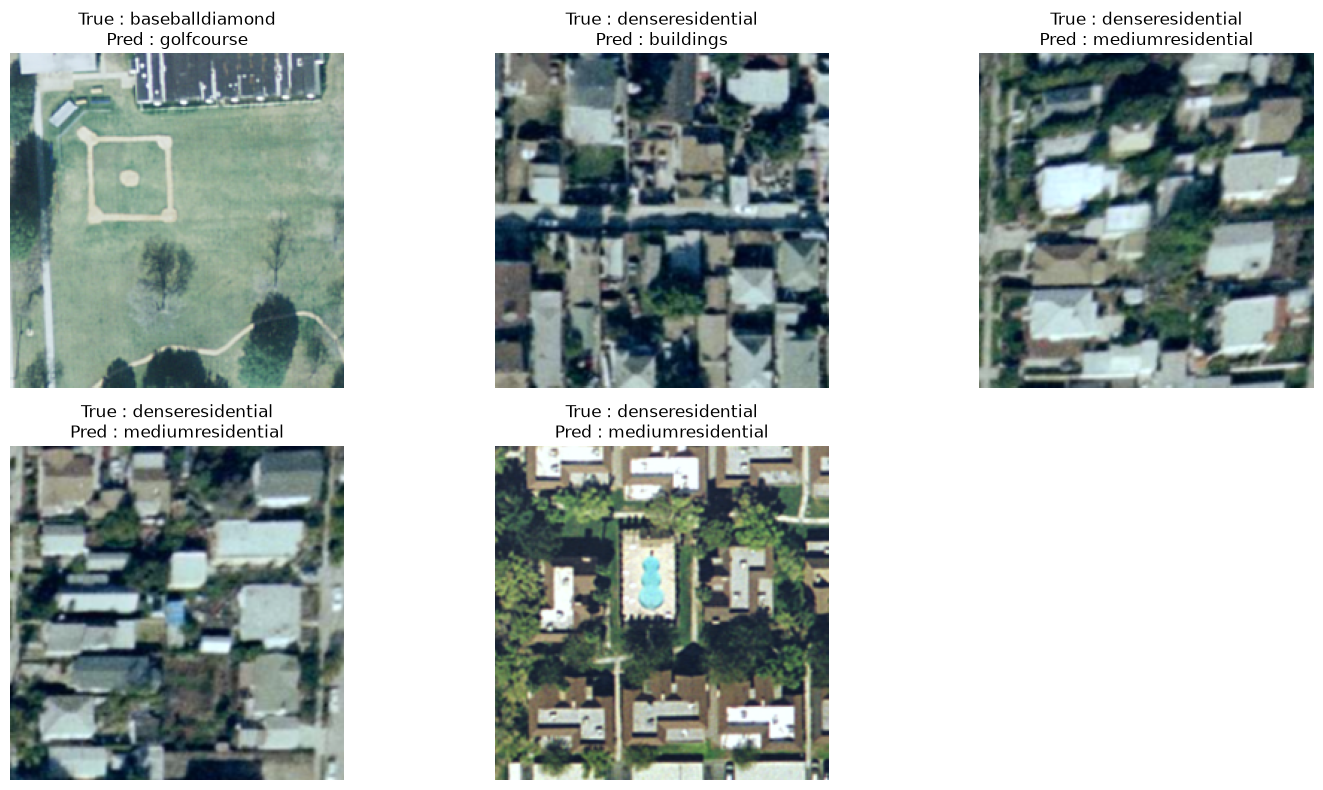

In [7]:
classes = dataset.classes

plt.figure(figsize=(15,8))

for i in range(min(5,len(misclassified))):

    image,true_label,pred_label = misclassified[i]

    img=image.squeeze().permute(1,2,0)

    img=img.numpy()

    img=img*0.229+0.485

    img=img.clip(0,1)

    plt.subplot(2,3,i+1)

    plt.imshow(img)

    plt.title(

        f"True : {classes[true_label]}\n"

        f"Pred : {classes[pred_label]}"

    )

    plt.axis("off")

plt.tight_layout()

plt.show()

In [11]:
def generate_reason(actual, predicted):

    residential = {"denseresidential", "mediumresidential", "sparseresidential"}
    vegetation = {"forest", "chaparral", "golfcourse", "baseballdiamond", "pasture"}
    urban = {"buildings", "storagetanks", "overpass", "intersection"}

    if actual == predicted:
        return "Correct classification."

    if actual in residential and predicted in residential:
        return "Both classes represent residential regions with similar building layouts and densities."

    if actual in vegetation and predicted in vegetation:
        return "Both classes contain vegetation with similar color, texture, and spatial patterns."

    if actual in urban and predicted in urban:
        return "Urban structures share similar geometric patterns and man-made features."

    return "The two classes exhibit similar visual characteristics, causing confusion during feature extraction."


rows = []

for i in range(min(5, len(misclassified))):

    _, true_label, pred_label = misclassified[i]

    actual = classes[true_label]
    predicted = classes[pred_label]

    rows.append({
        "Actual": actual,
        "Predicted": predicted,
        "Possible Reason": generate_reason(actual, predicted)
    })

df = pd.DataFrame(rows)
df

,Actual,Predicted,Possible Reason
0,baseballdiamond,golfcourse,Both classes contain vegetation with similar c...
1,denseresidential,buildings,The two classes exhibit similar visual charact...
2,denseresidential,mediumresidential,Both classes represent residential regions wit...
3,denseresidential,mediumresidential,Both classes represent residential regions wit...
4,denseresidential,mediumresidential,Both classes represent residential regions wit...
